# Visualize Doctor Breath Labels

Load an exported breath-label `.pkl`, inspect annotator outputs, and visualize one breath at a time.

In [1]:
from pathlib import Path

import ast
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams["figure.figsize"] = (12, 4)

In [2]:
BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

EXPORT_ROOT = BASE_DIR / "stored_results" / "05_breath_label_exports"
VERSION_TAG = "20260301"
PATIENT_ID = "03"
PKL_PATH = EXPORT_ROOT / VERSION_TAG / f"patient_{PATIENT_ID}" / f"BB_patient_{PATIENT_ID}_clustered_breaths__doctor_labels.pkl"

if not PKL_PATH.exists():
    raise FileNotFoundError(f"Exported PKL not found: {PKL_PATH}")

df = pd.read_pickle(PKL_PATH)
doctor_cols = [c for c in df.columns if c.startswith("doctor__")]
label_cols = [c for c in doctor_cols if c.endswith("__label")]

print("Loaded:", PKL_PATH)
print("Shape:", df.shape)
print("Doctor label columns:", label_cols)
display(df.head())

Loaded: /home/jhkim/NAVA/03_LABEL_BREATH/stored_results/05_breath_label_exports/20260301/patient_03/BB_patient_03_clustered_breaths__doctor_labels.pkl
Shape: (1418, 30)
Doctor label columns: ['doctor__Test__label']


,patient_id,breath_id,breath_label,v_start_idx,v_end_idx,v_start_t,v_end_t,breath_duration_sec,n_peaks,peak_indices,...,right_pad_len,target_len,cluster_label,major_cluster,anomaly_score,AE_abnormal,doctor__Test__item_id,doctor__Test__label,doctor__Test__comment,doctor__Test__labeled_at
0,03,0,breath_0,1541,1679,15430.0,16810.0,1.38,1,[1592],...,711,1494,1,True,0.000099,False,NaN,NaN,NaN,NaN
1,03,1,breath_1,1679,1943,16810.0,19450.0,2.64,1,[1748],...,603,1494,0,False,0.000282,True,03|breath|1,Normal,,2026-04-14T13:30:01
2,03,2,breath_2,1943,2151,19450.0,21530.0,2.08,1,[2044],...,691,1494,1,True,0.000034,False,NaN,NaN,NaN,NaN
3,03,3,breath_3,2151,2839,21530.0,28410.0,6.88,1,[2709],...,668,1494,1,True,0.000942,True,NaN,NaN,NaN,NaN
4,03,4,breath_4,2839,2996,28410.0,29980.0,1.57,1,[2905],...,707,1494,1,True,0.000045,False,NaN,NaN,NaN,NaN


In [3]:
summary_frames = []
for label_col in label_cols:
    annotator = label_col[len("doctor__") : -len("__label")]
    counts = (
        df[label_col]
        .fillna("UNLABELED")
        .replace("", "UNLABELED")
        .value_counts(dropna=False)
        .rename_axis("label")
        .reset_index(name="count")
    )
    counts.insert(0, "annotator", annotator)
    summary_frames.append(counts)

summary_df = pd.concat(summary_frames, ignore_index=True) if summary_frames else pd.DataFrame()
display(summary_df)

,annotator,label,count
0,Test,UNLABELED,1405
1,Test,Sigh,4
2,Test,Hiccup,4
3,Test,Normal,3
4,Test,NotSure,2


In [4]:
anomaly_mask = df["AE_abnormal"].fillna(False).astype(bool)
anomaly_total = int(anomaly_mask.sum())

progress_rows = []
for label_col in label_cols:
    annotator = label_col[len("doctor__") : -len("__label")]
    labeled_mask = df[label_col].fillna("").astype(str).str.strip() != ""
    anomaly_labeled = int((anomaly_mask & labeled_mask).sum())
    progress_rows.append(
        {
            "annotator": annotator,
            "anomaly_total": anomaly_total,
            "anomaly_labeled": anomaly_labeled,
            "anomaly_remaining": anomaly_total - anomaly_labeled,
            "anomaly_label_rate": round(100.0 * anomaly_labeled / anomaly_total, 2) if anomaly_total else 0.0,
        }
    )

anomaly_progress_df = pd.DataFrame(progress_rows)
display(anomaly_progress_df)

,annotator,anomaly_total,anomaly_labeled,anomaly_remaining,anomaly_label_rate
0,Test,41,13,28,31.71


In [5]:
SELECTED_LABEL = "Normal"  # change this to NeedSplit / Apnea / Hiccup / NotSure / etc.

filtered = df.copy()
for label_col in label_cols:
    filtered = filtered[filtered[label_col].fillna("") == SELECTED_LABEL]

print("Filtered rows:", len(filtered))
display(filtered.head(20))

Filtered rows: 3


,patient_id,breath_id,breath_label,v_start_idx,v_end_idx,v_start_t,v_end_t,breath_duration_sec,n_peaks,peak_indices,...,right_pad_len,target_len,cluster_label,major_cluster,anomaly_score,AE_abnormal,doctor__Test__item_id,doctor__Test__label,doctor__Test__comment,doctor__Test__labeled_at
1,03,1,breath_1,1679,1943,16810.0,19450.0,2.64,1,[1748],...,603,1494,0,False,0.000282,True,03|breath|1,Normal,,2026-04-14T13:30:01
36,03,36,breath_36,12702,12949,127040.0,129510.0,2.47,1,[12854],...,703,1494,0,False,0.000115,True,03|breath|36,Normal,,2026-04-14T13:32:55
38,03,38,breath_38,13053,13301,130550.0,133030.0,2.48,1,[13158],...,655,1494,0,False,0.000203,True,03|breath|38,Normal,,2026-04-14T13:33:01


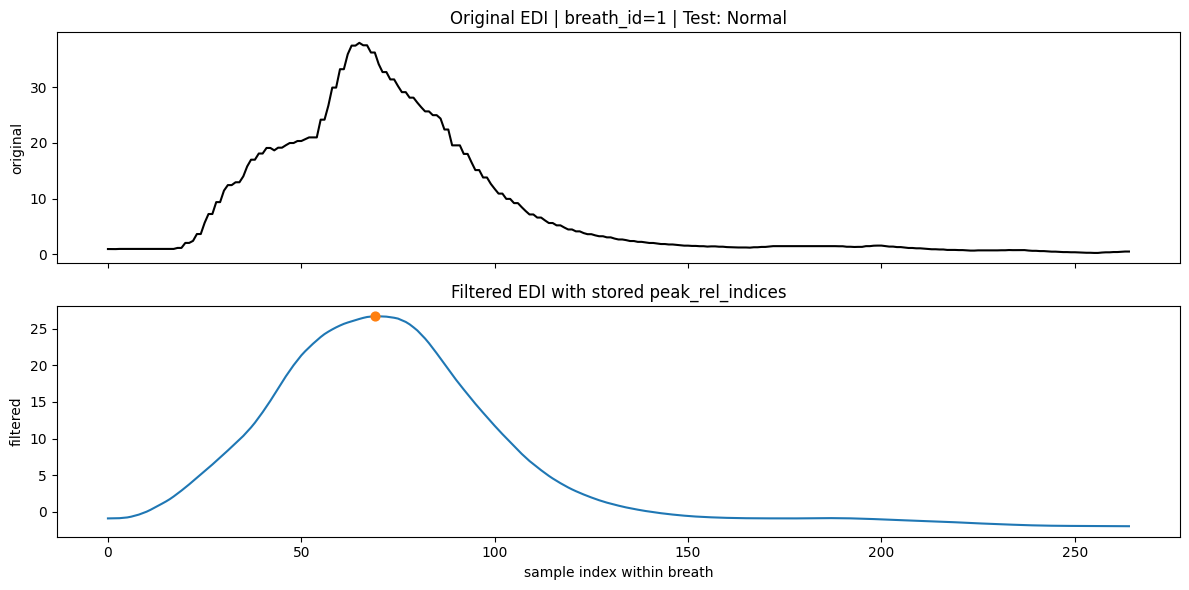

,patient_id,breath_id,breath_label,v_start_idx,v_end_idx,v_start_t,v_end_t,breath_duration_sec,n_peaks,peak_indices,...,right_pad_len,target_len,cluster_label,major_cluster,anomaly_score,AE_abnormal,doctor__Test__item_id,doctor__Test__label,doctor__Test__comment,doctor__Test__labeled_at
1,03,1,breath_1,1679,1943,16810.0,19450.0,2.64,1,[1748],...,603,1494,0,False,0.000282,True,03|breath|1,Normal,,2026-04-14T13:30:01


In [6]:
def _to_signal_array(value):
    if isinstance(value, np.ndarray):
        return value.astype(float)
    if isinstance(value, list):
        return np.asarray(value, dtype=float)
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
        except Exception:
            return np.asarray([], dtype=float)
        if isinstance(parsed, list):
            return np.asarray(parsed, dtype=float)
    return np.asarray([], dtype=float)


ROW_INDEX = 1  # choose a row index from df.index or filtered.index
row = df.loc[ROW_INDEX]

orig = _to_signal_array(row.get("original_edi_signal"))
filt = _to_signal_array(row.get("filtered_edi_signal"))
peak_rel = row.get("peak_rel_indices", [])
if not isinstance(peak_rel, list):
    peak_rel = []

label_text = []
for label_col in label_cols:
    annotator = label_col[len("doctor__") : -len("__label")]
    label_val = row.get(label_col)
    if pd.notna(label_val) and str(label_val).strip():
        label_text.append(f"{annotator}: {label_val}")

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 6))

axes[0].plot(orig, color="black", linewidth=1.5)
axes[0].set_title(f"Original EDI | breath_id={row['breath_id']} | {' | '.join(label_text) if label_text else 'unlabeled'}")
axes[0].set_ylabel("original")

axes[1].plot(filt, color="tab:blue", linewidth=1.5)
if peak_rel:
    valid_peak_rel = [p for p in peak_rel if 0 <= int(p) < len(filt)]
    axes[1].scatter(valid_peak_rel, filt[valid_peak_rel], color="tab:orange", s=40, zorder=3)
axes[1].set_title("Filtered EDI with stored peak_rel_indices")
axes[1].set_ylabel("filtered")
axes[1].set_xlabel("sample index within breath")

plt.tight_layout()
plt.show()

display(row.to_frame().T)